# Hero DMC Heart Institute: Cardiology Admissions Analysis (2017-19)

**Data:** "Hospital Admissions Data", Hero DMC Heart Institute, Ludhiana, India (Kaggle, CC BY-NC-SA 4.0). The data is not included in this repo; download it from Kaggle.

**Tools:** Python (pandas, matplotlib), Google Colab

## Key findings (14,872 admissions from 12,244 patients, after cleaning)

1. 73.4% of admissions were patients aged 45 to 74.
2. Emergency admissions stayed 7.0 days on average, versus 5.1 days for OPD admissions.
3. Patients with chronic kidney disease (CKD) stayed about 2 days longer (8.3 vs 6.2 days), in both emergency and OPD admissions.
4. Among emergency admissions, in-hospital deaths were 18.0% with CKD versus 9.4% without.
5. Diabetic patients stayed about 0.8 days longer, but had a lower share of in-hospital deaths (8.2% vs 11.6% in emergency admissions). The reason is unclear from this data.

## Data cleaning

- The date columns mixed day/month and month/day formats. I identified the format for each row by checking it against the recorded length of stay.
- Removed 885 exact duplicate rows (identical except the serial number).
- 63 rows had unreadable dates; they were kept with the dates left blank.

**Limits:** one hospital's cardiology unit, counts are admissions (not patients), and these are patterns in the data, not causes.

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH =  "/content/HDHI Admission data.csv"   # change if your file is elsewhere
os.makedirs("charts", exist_ok=True)

raw = pd.read_csv(DATA_PATH)
raw.columns = [re.sub(r"[^a-z0-9]+", "_", c.strip().lower()).strip("_") for c in raw.columns]
print("Rows, columns:", raw.shape)
raw.head()

Rows, columns: (15757, 56)


,sno,mrd_no,d_o_a,d_o_d,age,gender,rural,type_of_admission_emergency_opd,month_year,duration_of_stay,...,congenital,uti,neuro_cardiogenic_syncope,orthostatic,infective_endocarditis,dvt,cardiogenic_shock,shock,pulmonary_embolism,chest_infection
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,Apr-17,5,...,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,Apr-17,8,...,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,Apr-17,23,...,0,0,0,0,0,0,0,0,0,0


In [2]:
def parse(col, fmt):
    return pd.to_datetime(raw[col], format=fmt, errors="coerce")

mdy_a, mdy_d = parse("d_o_a", "%m/%d/%Y"), parse("d_o_d", "%m/%d/%Y")
dmy_a, dmy_d = parse("d_o_a", "%d/%m/%Y"), parse("d_o_d", "%d/%m/%Y")

los = raw["duration_of_stay"]
ok_mdy = ((mdy_d - mdy_a).dt.days + 1) == los
ok_dmy = ((dmy_d - dmy_a).dt.days + 1) == los

month = pd.to_datetime(raw["month_year"], format="%b-%y", errors="coerce").dt.to_period("M")
good_mdy = ok_mdy & (mdy_a.dt.to_period("M") == month)
good_dmy = ok_dmy & (dmy_a.dt.to_period("M") == month)

raw["date_flag"] = ~(good_mdy | good_dmy)
raw["d_o_a"] = mdy_a.where(good_mdy, dmy_a.where(good_dmy, pd.NaT))
raw["d_o_d"] = mdy_d.where(good_mdy, dmy_d.where(good_dmy, pd.NaT))
print("Rows with unreadable dates (dates left blank):", raw["date_flag"].sum())

Rows with unreadable dates (dates left blank): 63


In [3]:
dup_cols = [c for c in raw.columns if c not in ["sno", "date_flag"]]
df_clean = raw.drop_duplicates(subset=dup_cols).copy()

print("Rows in file:", len(raw))
print("Exact duplicates removed:", len(raw) - len(df_clean))
print("Admissions after cleaning:", len(df_clean))
print("Unique patients:", df_clean["mrd_no"].nunique())

Rows in file: 15757
Exact duplicates removed: 885
Admissions after cleaning: 14872
Unique patients: 12244


age_group
<30       2.1
30-44     7.8
45-59    29.8
60-74    43.6
75+      16.6
Name: proportion, dtype: float64
Aged 45-74: 73.4 %


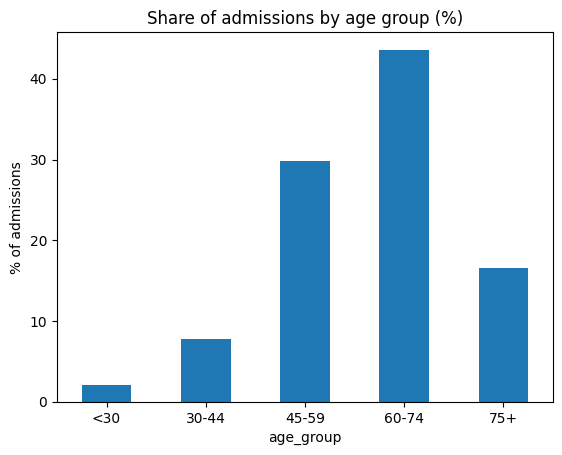

In [4]:
df_clean["age_group"] = pd.cut(df_clean["age"], bins=[0, 30, 45, 60, 75, 120], right=False,
                               labels=["<30", "30-44", "45-59", "60-74", "75+"])
age_share = (df_clean["age_group"].value_counts(normalize=True).sort_index() * 100).round(1)
print(age_share)
print("Aged 45-74:", round(age_share["45-59"] + age_share["60-74"], 1), "%")

age_share.plot(kind="bar", rot=0, title="Share of admissions by age group (%)")
plt.ylabel("% of admissions")
plt.savefig("charts/age_groups.png", dpi=200, bbox_inches="tight")
plt.show()

                count  mean  median
admission_type                     
Emergency       10325   7.0     6.0
OPD              4547   5.1     4.0


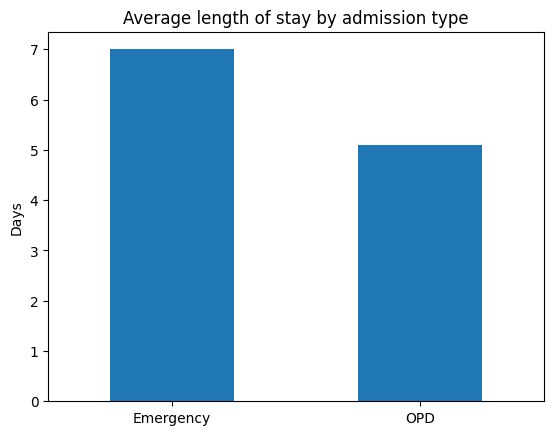

In [5]:
df_clean["admission_type"] = df_clean["type_of_admission_emergency_opd"].map({"E": "Emergency", "O": "OPD"})

by_type = df_clean.groupby("admission_type")["duration_of_stay"].agg(["count", "mean", "median"]).round(1)
print(by_type)

by_type["mean"].plot(kind="bar", rot=0, title="Average length of stay by admission type")
plt.ylabel("Days")
plt.xlabel("")
plt.savefig("charts/stay_by_admission_type.png", dpi=200, bbox_inches="tight")
plt.show()

              admissions_with  avg_stay_without  avg_stay_with  extra_days
condition                                                                 
CKD                      1479               6.2            8.3         2.2
Diabetes                 4929               6.1            6.9         0.8
Hypertension             7213               6.3            6.5         0.2
CAD                      9917               6.3            6.4         0.1
Alcohol                   995               6.4            6.2        -0.2
Smoking                   776               6.4            6.0        -0.4


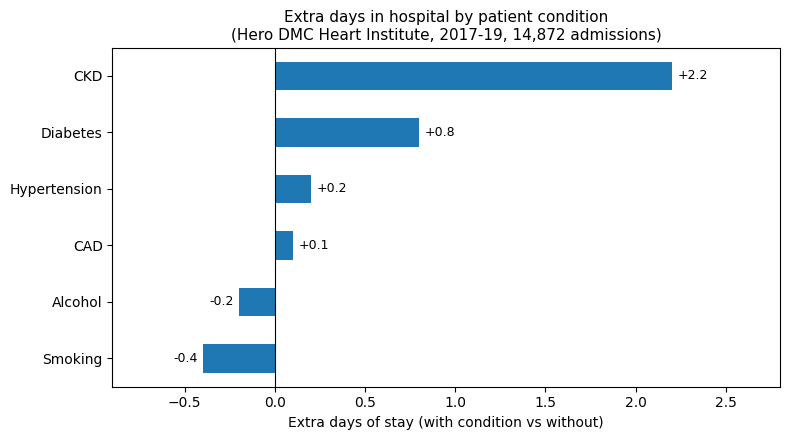

In [6]:
conditions = {"CKD": "ckd", "Diabetes": "dm", "Hypertension": "htn",
              "CAD": "cad", "Alcohol": "alcohol", "Smoking": "smoking"}

rows = []
for name, col in conditions.items():
    g = df_clean.groupby(col)["duration_of_stay"].mean()
    rows.append({"condition": name,
                 "admissions_with": int((df_clean[col] == 1).sum()),
                 "avg_stay_without": round(g.loc[0], 1),
                 "avg_stay_with": round(g.loc[1], 1),
                 "extra_days": round(g.loc[1] - g.loc[0], 1)})
stay_gap = pd.DataFrame(rows).set_index("condition").sort_values("extra_days", ascending=False)
print(stay_gap)

plot_data = stay_gap["extra_days"].sort_values()
ax = plot_data.plot(kind="barh", figsize=(8, 4.5), color="#1f77b4")
ax.set_title(f"Extra days in hospital by patient condition\n(Hero DMC Heart Institute, 2017-19, {len(df_clean):,} admissions)", fontsize=11)
ax.set_xlabel("Extra days of stay (with condition vs without)")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(plot_data.min() - 0.5, plot_data.max() + 0.6)
for i, v in enumerate(plot_data):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.savefig("charts/condition_vs_stay.png", dpi=200)
plt.show()

In [7]:
print(df_clean.groupby(["admission_type", "ckd"])["duration_of_stay"]
      .agg(["count", "mean", "median"]).round(1))
print("\nAverage age by CKD status:")
print(df_clean.groupby("ckd")["age"].mean().round(1))

                    count  mean  median
admission_type ckd                     
Emergency      0     9124   6.8     6.0
               1     1201   8.6     7.0
OPD            0     4269   4.9     4.0
               1      278   7.3     6.0

Average age by CKD status:
ckd
0    61.0
1    65.1
Name: age, dtype: float64


In [8]:
print(df_clean["outcome"].value_counts())
print((df_clean["outcome"].value_counts(normalize=True) * 100).round(1))

df_clean["died"] = (df_clean["outcome"] == "EXPIRY").astype(int)

def death_rate(col, data=df_clean):
    t = data.groupby(col, observed=True)["died"].agg(["count", "mean"])
    t["death_%"] = (t["mean"] * 100).round(1)
    return t[["count", "death_%"]]

for label, col in {"Age group": "age_group", "Admission type": "admission_type",
                   "CKD": "ckd", "Diabetes": "dm"}.items():
    print(f"\n{label}")
    print(death_rate(col))

outcome
DISCHARGE    12916
EXPIRY        1105
DAMA           851
Name: count, dtype: int64
outcome
DISCHARGE    86.8
EXPIRY        7.4
DAMA          5.7
Name: proportion, dtype: float64

Age group
           count  death_%
age_group                
<30          314      8.0
30-44       1163      4.8
45-59       4436      5.4
60-74       6485      7.9
75+         2474     10.9

Admission type
                count  death_%
admission_type                
Emergency       10325     10.4
OPD              4547      0.6

CKD
     count  death_%
ckd                
0    13393      6.6
1     1479     15.1

Diabetes
    count  death_%
dm                
0    9943      8.2
1    4929      5.9



CKD (emergency admissions only)
     count  death_%
ckd                
0     9124      9.4
1     1201     18.0

DM (emergency admissions only)
    count  death_%
dm                
0    6799     11.6
1    3526      8.2


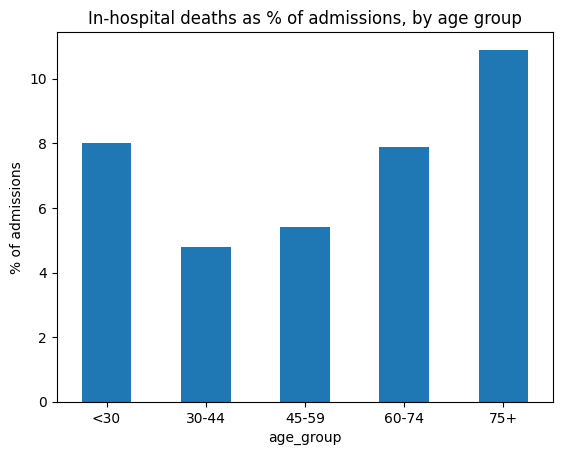

In [9]:
emergency = df_clean[df_clean["admission_type"] == "Emergency"]
for col in ["ckd", "dm"]:
    print(f"\n{col.upper()} (emergency admissions only)")
    print(death_rate(col, emergency))

(df_clean.groupby("age_group", observed=True)["died"].mean() * 100).round(1).plot(
    kind="bar", rot=0, title="In-hospital deaths as % of admissions, by age group")
plt.ylabel("% of admissions")
plt.savefig("charts/deaths_by_age.png", dpi=200, bbox_inches="tight")
plt.show()